# Visual Psychophysics Battery analysis

This notebook reads the simulated PsyNet export and summarizes the three battery blocks.

In [1]:
from pathlib import Path
import ast
import tempfile
import zipfile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams['figure.dpi'] = 50
N_COLORS = 30
zip_path = Path('../simulated_data.zip')
assert zip_path.exists(), zip_path
with tempfile.TemporaryDirectory() as tmpdir:
    with zipfile.ZipFile(zip_path) as archive:
        archive.extractall(tmpdir)
    trial_csv = next(Path(tmpdir).rglob('regular/basic_data/trial.csv'))
    participant_csv = next(Path(tmpdir).rglob('regular/basic_data/participant.csv'))
    trials = pd.read_csv(trial_csv)
    participants = pd.read_csv(participant_csv)

trials['answer_dict'] = trials['answer'].apply(ast.literal_eval)
answers = pd.json_normalize(trials['answer_dict'])
trials = pd.concat([trials.drop(columns=['answer_dict']), answers.add_prefix('answer_')], axis=1)
print(f'Read {len(trials)} trials from {participants.shape[0]} participants.')
trials.head()

Read 720 trials from 24 participants.


,trial_id,participant_id,block,definition,answer,failed,answer_block,answer_trial_id,answer_left_id,answer_right_id,...,answer_rating,answer_rating_normalized,answer_set_size,answer_items,answer_positions,answer_probe_id,answer_probe_condition,answer_response_item_number,answer_response_color_id,answer_correct_item_number
0,discrimination_090,1,discrimination,"{'trial_id': 'discrimination_090', 'block': 'd...","{'block': 'discrimination', 'trial_id': 'discr...",False,discrimination,discrimination_090,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,discrimination_168,1,discrimination,"{'trial_id': 'discrimination_168', 'block': 'd...","{'block': 'discrimination', 'trial_id': 'discr...",False,discrimination,discrimination_168,18.0,18.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,discrimination_112,1,discrimination,"{'trial_id': 'discrimination_112', 'block': 'd...","{'block': 'discrimination', 'trial_id': 'discr...",False,discrimination,discrimination_112,22.0,22.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,similarity_358,12,similarity,"{'trial_id': 'similarity_358', 'block': 'simil...","{'block': 'similarity', 'trial_id': 'similarit...",False,similarity,similarity_358,15.0,28.0,...,1.0,0.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,discrimination_042,1,discrimination,"{'trial_id': 'discrimination_042', 'block': 'd...","{'block': 'discrimination', 'trial_id': 'discr...",False,discrimination,discrimination_042,12.0,12.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Block-level summaries

In [2]:
block_counts = trials.groupby('block').size().rename('n_trials').to_frame()
rt_summary = trials.groupby('block')['answer_rt_msec'].agg(['mean', 'median', 'std']).round(1)
summary = block_counts.join(rt_summary)
summary

,n_trials,mean,median,std
block,,,,
discrimination,240,1108.8,1079.0,395.9
identification,240,1150.6,1143.5,409.2
similarity,240,1117.9,1122.5,390.0


In [3]:
discrimination = trials[trials['block'] == 'discrimination'].copy()
similarity = trials[trials['block'] == 'similarity'].copy()
identification = trials[trials['block'] == 'identification'].copy()

discrimination_perf = discrimination.groupby('answer_condition')['answer_correct'].mean().rename('accuracy').to_frame().round(3)
similarity_ratings = similarity['answer_rating'].describe().round(3).to_frame('rating')
identification_present = identification[identification['answer_probe_condition'] == 'present']
identification_perf = identification_present.groupby('answer_set_size')['answer_correct'].mean().rename('present_probe_accuracy').to_frame().round(3)
print('Discrimination accuracy by condition')
display(discrimination_perf)
print('Similarity rating distribution')
display(similarity_ratings)
print('Identification present-probe accuracy by set size')
display(identification_perf)

Discrimination accuracy by condition


,accuracy
answer_condition,
different,0.858333
same,0.958333


Similarity rating distribution


,rating
count,240.000
mean,2.092
std,1.220
min,1.000
25%,1.000
50%,2.000
75%,3.000
max,5.000


Identification present-probe accuracy by set size


,present_probe_accuracy
answer_set_size,
3.0,0.928571
4.0,0.785714
5.0,0.878049


## Empirical matrices

The matrices share the 30-color stimulus space. Values are normalized to 0-1 as requested.

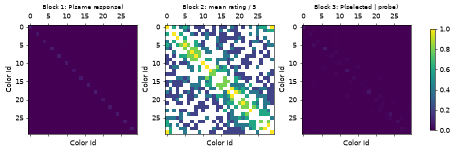

In [4]:
disc_matrix = np.zeros((N_COLORS, N_COLORS), dtype=float)
for _, row in discrimination.iterrows():
    if row['answer_response'] == 'same':
        i, j = int(row['answer_left_id']), int(row['answer_right_id'])
        disc_matrix[i, j] += 1
        disc_matrix[j, i] += 1
if len(discrimination):
    disc_matrix /= len(discrimination)

sim_matrix = np.full((N_COLORS, N_COLORS), np.nan)
for (left, right), group in similarity.groupby(['answer_left_id', 'answer_right_id']):
    value = group['answer_rating'].mean() / 5
    i, j = int(left), int(right)
    sim_matrix[i, j] = value
    sim_matrix[j, i] = value

ident_matrix = np.zeros((N_COLORS, N_COLORS), dtype=float)
for _, row in identification.iterrows():
    probe = int(row['answer_probe_id'])
    selected = int(row['answer_response_color_id'])
    ident_matrix[probe, selected] += 1
if len(identification):
    ident_matrix /= len(identification)

fig, axes = plt.subplots(1, 3, figsize=(9, 3), constrained_layout=True)
plots = [
    (disc_matrix, 'Block 1: P(same response)'),
    (sim_matrix, 'Block 2: mean rating / 5'),
    (ident_matrix, 'Block 3: P(selected | probe)'),
]
image = None
for ax, (matrix, title) in zip(axes, plots):
    image = ax.matshow(matrix, vmin=0, vmax=1, cmap='viridis')
    ax.set_title(title, fontsize=9)
    ax.set_xlabel('Color id')
    ax.set_ylabel('Color id')
fig.colorbar(image, ax=axes, shrink=0.75)
fig.savefig('empirical_matrices.png', bbox_inches='tight')
plt.show()

## Interpretation

The simulated dataset contains all three experimental blocks for each bot participant. The discrimination, similarity, and identification matrices are sparse because each participant receives 10 sampled trials per block, but their values follow the intended hue-distance model: exact or nearby colors tend to produce more same responses, higher similarity ratings, and more probe-to-choice selections.